# Road Detect Monitoring System
Briefly, this project analyzes road videos to extract representative frames, assess noise degradations, clean the frames, and detect common road defects. The goal is to support monitoring by highlighting cracks, pedestrian crossings, ravelling, and potholes in a consistent, repeatable pipeline.

## Table of Contents (What We Did)
1. Extract 30 equally distributed frames from the input video.
2. Analyze noise degradations on extracted frames:
   - Gaussian noise
   - Salt & pepper noise
   - Uniform noise
   - Speckle noise
3. Convert selected frames to grayscale and plot histograms.
4. Classify noise type per frame and generate a noise report.
5. Apply noise-specific filtering and save cleaned frames.
6. Visualize original vs. filtered frames with histogram comparisons.
7. Detect road defects:
   - Edge cracking
   - Pedestrian crossing markings
   - Ravelling
   - Potholes
8. Summarize outputs and export reports/images.

first we get the video

In [243]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from pathlib import Path

print("All libraries imported successfully!")

All libraries imported successfully!


In [244]:
video_path = 'videos/all_in_one.mp4'

# Verify video exists
if not os.path.exists(video_path):
    print(f"Error: Video file not found at {video_path}")
    print("\nAvailable videos:")
    if os.path.exists('videos'):
        for f in os.listdir('videos'):
            if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
                print(f"  - {f}")
else:
    print(f"✓ Video found: {video_path}")

✓ Video found: videos/all_in_one.mp4


# 1. Extract 30 Equally Distributed Frames
Extract 30 frames equally distributed throughout the entire video

In [245]:
# Create output folder for 30 frames
extracted_30_frames_folder = "extracted_30_frames"
os.makedirs(extracted_30_frames_folder, exist_ok=True)

# Open the video file
cap = cv2.VideoCapture(video_path)

# Get video properties
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

if total_frames == 0:
    print(f"Error: Could not read video {video_path}")
else:
    print(f"Video: {video_path}")
    print(f"Total frames: {total_frames}")
    print(f"FPS: {fps}")
    
    # Calculate frame indices for 30 equally distributed frames
    # We want frames evenly spaced across the entire video
    frame_indices = np.linspace(0, total_frames - 1, 30, dtype=int)
    frame_indices = sorted(list(set(frame_indices)))  # Remove duplicates and sort
    
    if len(frame_indices) < 30:
        # If we have duplicates, fill in gaps
        frame_indices = np.linspace(0, total_frames - 1, 30, dtype=int)
    
    extracted_count = 0
    
    for idx, frame_num in enumerate(frame_indices):
        # Set the frame position
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        
        # Read the frame
        ret, frame = cap.read()
        
        if ret:
            # Save the frame with a zero-padded filename
            frame_name = f"frame_{idx+1:02d}.jpg"
            frame_path = os.path.join(extracted_30_frames_folder, frame_name)
            
            cv2.imwrite(frame_path, frame)
            extracted_count += 1

        else:
            print(f"  Warning: Failed to read frame {frame_num}")
    
    # Release the video capture
    cap.release()
    
    print(f"\n✓ Extraction Complete!")
    print(f"  Total frames extracted: {extracted_count}")
    print(f"  Output folder: {extracted_30_frames_folder}")
    
    # List the extracted frames
    extracted_files = sorted([f for f in os.listdir(extracted_30_frames_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
   
   

Video: videos/all_in_one.mp4
Total frames: 908
FPS: 30.0

✓ Extraction Complete!
  Total frames extracted: 30
  Output folder: extracted_30_frames


# 2. Noise Analysis and Filtering

## 2.1 Select 30 frames with visible noise

In [246]:

def compute_noise_score(image_path):
    """
    Returns a composite noise score for a frame.
    Higher score  →  more visible degradation.
    Combines: Laplacian variance, pixel-level std-dev,
              salt-and-pepper pixel ratio, and speckle estimate.
    """
    img   = cv2.imread(image_path)
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float64)

    # 1. Laplacian variance  (captures sharpness / texture noise)
    lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    # 2. Local std-dev via sliding window  (captures grain / speckle)
    blurred   = cv2.GaussianBlur(gray, (5, 5), 0)
    local_std = np.std(gray - blurred)

    # 3. Salt-and-pepper ratio  (pixels very close to 0 or 255)
    sp_ratio = (np.sum(gray <= 5) + np.sum(gray >= 250)) / gray.size

    # 4. Speckle estimate  (std / mean of small local patches)
    mean_val = np.mean(gray) + 1e-6
    speckle  = np.std(gray) / mean_val

    # Composite score (weights tuned for typical video frames)
    score = (0.4 * lap_var +
             0.3 * local_std * 10 +
             0.2 * sp_ratio * 10000 +
             0.1 * speckle * 100)
    return score

# ── Score every extracted frame ──────────────────────────────────
all_frames = sorted([
    f for f in os.listdir(extracted_30_frames_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

scores = {}
for fname in all_frames:
    path  = os.path.join(extracted_30_frames_folder, fname)
    scores[fname] = compute_noise_score(path)

# Sort by score descending and pick top 30
sorted_frames = sorted(scores.items(), key=lambda x: x[1], reverse=True)
selected_30   = [item[0] for item in sorted_frames[:30]]

print("✓ Top 30 frames selected by noise score:")
for rank, (fname, sc) in enumerate(sorted_frames[:30], 1):
    print(f"  {rank:02d}. {fname}  →  score = {sc:.2f}")

✓ Top 30 frames selected by noise score:
  01. frame_25.jpg  →  score = 1636.98
  02. frame_23.jpg  →  score = 1625.30
  03. frame_24.jpg  →  score = 1590.35
  04. frame_26.jpg  →  score = 1589.35
  05. frame_27.jpg  →  score = 1583.75
  06. frame_29.jpg  →  score = 1563.00
  07. frame_28.jpg  →  score = 1556.42
  08. frame_30.jpg  →  score = 1537.01
  09. frame_19.jpg  →  score = 704.41
  10. frame_18.jpg  →  score = 687.72
  11. frame_16.jpg  →  score = 669.70
  12. frame_17.jpg  →  score = 668.67
  13. frame_20.jpg  →  score = 640.35
  14. frame_22.jpg  →  score = 615.41
  15. frame_21.jpg  →  score = 560.17
  16. frame_02.jpg  →  score = 288.47
  17. frame_06.jpg  →  score = 232.86
  18. frame_03.jpg  →  score = 217.15
  19. frame_05.jpg  →  score = 215.18
  20. frame_07.jpg  →  score = 211.82
  21. frame_04.jpg  →  score = 161.52
  22. frame_01.jpg  →  score = 114.69
  23. frame_08.jpg  →  score = 39.16
  24. frame_12.jpg  →  score = 34.50
  25. frame_14.jpg  →  score = 32.47
  26

## 2.2 Grayscale conversion + Histogram plotting

In [247]:

grayscale_folder = "grayscale_frames"
histogram_folder = "histograms"
os.makedirs(grayscale_folder, exist_ok=True)
os.makedirs(histogram_folder, exist_ok=True)

grayscale_images = {}   # fname → grayscale ndarray (kept in memory for later cells)

for fname in selected_30:
    src  = os.path.join(extracted_30_frames_folder, fname)
    img  = cv2.imread(src)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ── Save grayscale image ─────────────────────────────────
    gray_path = os.path.join(grayscale_folder, fname)
    cv2.imwrite(gray_path, gray)
    grayscale_images[fname] = gray

    # ── Plot & save histogram ────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Frame: {fname}", fontsize=12, fontweight='bold')

    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title("Grayscale Image")
    axes[0].axis('off')

    axes[1].hist(gray.ravel(), bins=256, range=(0, 255),
                 color='steelblue', alpha=0.85, edgecolor='none')
    axes[1].set_title("Pixel Intensity Histogram")
    axes[1].set_xlabel("Pixel Intensity")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(axis='y', alpha=0.4)

    hist_path = os.path.join(histogram_folder, fname.replace('.jpg', '_hist.png'))
    plt.tight_layout()
    plt.savefig(hist_path, dpi=100)
    plt.close()

print(f"✓ Grayscale images saved  →  '{grayscale_folder}/'")
print(f"✓ Histograms saved        →  '{histogram_folder}/'")

✓ Grayscale images saved  →  'grayscale_frames/'
✓ Histograms saved        →  'histograms/'


## 2.3 Noise detection & classification

In [248]:
# ─────────────────────────────────────────────────────────────
# CELL 6 : Noise Detection & Classification
# ─────────────────────────────────────────────────────────────

def detect_noise_type(gray):
    """
    Analyses a grayscale frame and returns a dict with:
      - detected noise types (bool flags)
      - key statistics used for the decision
    """
    h, w  = gray.shape
    flat  = gray.astype(np.float64).ravel()

    mean_val  = np.mean(flat)
    std_val   = np.std(flat)
    skewness  = pd.Series(flat).skew()
    kurtosis  = pd.Series(flat).kurt()

    # ── Salt-and-Pepper ──────────────────────────────────────
    sp_ratio = (np.sum(gray <= 5) + np.sum(gray >= 250)) / gray.size
    has_sp   = sp_ratio > 0.002   # >0.2 % extreme pixels

    # ── Gaussian noise ───────────────────────────────────────
    # Residual after strong Gaussian blur approximates additive noise
    blurred     = cv2.GaussianBlur(gray, (15, 15), 0).astype(np.float64)
    residual    = gray.astype(np.float64) - blurred
    res_std     = np.std(residual)
    has_gauss   = (res_std > 8) and (abs(skewness) < 1.5)

    # ── Speckle noise ────────────────────────────────────────
    # Speckle → variance proportional to local mean (multiplicative)
    local_mean  = cv2.GaussianBlur(gray, (9, 9), 0).astype(np.float64) + 1e-6
    speckle_idx = np.mean((residual / local_mean) ** 2)
    has_speckle = speckle_idx > 0.004

    # ── Uniform noise ────────────────────────────────────────
    # Uniform distribution → platykurtic (kurtosis < −0.5)
    has_uniform = kurtosis < -0.5 and not has_sp

    return {
        "mean":        round(mean_val, 2),
        "std":         round(std_val,  2),
        "skewness":    round(skewness, 3),
        "kurtosis":    round(kurtosis, 3),
        "sp_ratio":    round(sp_ratio, 5),
        "res_std":     round(res_std,  3),
        "speckle_idx": round(speckle_idx, 5),
        "gaussian":    has_gauss,
        "salt_pepper": has_sp,
        "uniform":     has_uniform,
        "speckle":     has_speckle,
    }

# ── Run detection on all selected frames ─────────────────────
noise_report = {}
for fname, gray in grayscale_images.items():
    noise_report[fname] = detect_noise_type(gray)

# ── Summary table ─────────────────────────────────────────────
rows = []
for fname, info in noise_report.items():
    detected = [k for k in ("gaussian", "salt_pepper", "uniform", "speckle")
                if info[k]]
    rows.append({
        "Frame":       fname,
        "Mean":        info["mean"],
        "Std":         info["std"],
        "Skewness":    info["skewness"],
        "Kurtosis":    info["kurtosis"],
        "SP_Ratio":    info["sp_ratio"],
        "Res_Std":     info["res_std"],
        "Gaussian":    "✓" if info["gaussian"]    else "–",
        "Salt&Pepper": "✓" if info["salt_pepper"] else "–",
        "Uniform":     "✓" if info["uniform"]     else "–",
        "Speckle":     "✓" if info["speckle"]     else "–",
        "Detected":    ", ".join(detected) if detected else "clean",
    })

df_report = pd.DataFrame(rows)
print("─" * 90)
print("NOISE DETECTION REPORT")
print("─" * 90)
print(df_report[["Frame","Gaussian","Salt&Pepper","Uniform","Speckle","Detected"]].to_string(index=False))
print("─" * 90)

# Save report to CSV
df_report.to_csv("noise_detection_report.csv", index=False)
print("\n✓ Full report saved  →  'noise_detection_report.csv'")

──────────────────────────────────────────────────────────────────────────────────────────
NOISE DETECTION REPORT
──────────────────────────────────────────────────────────────────────────────────────────
       Frame Gaussian Salt&Pepper Uniform Speckle                       Detected
frame_25.jpg        ✓           ✓       –       ✓ gaussian, salt_pepper, speckle
frame_23.jpg        ✓           ✓       –       ✓ gaussian, salt_pepper, speckle
frame_24.jpg        ✓           ✓       –       ✓ gaussian, salt_pepper, speckle
frame_26.jpg        ✓           ✓       –       ✓ gaussian, salt_pepper, speckle
frame_27.jpg        ✓           ✓       –       ✓ gaussian, salt_pepper, speckle
frame_29.jpg        ✓           ✓       –       ✓ gaussian, salt_pepper, speckle
frame_28.jpg        ✓           ✓       –       ✓ gaussian, salt_pepper, speckle
frame_30.jpg        ✓           ✓       –       ✓ gaussian, salt_pepper, speckle
frame_19.jpg        ✓           –       –       ✓              gau

## 2.4 Apply noise-specific filters

In [249]:
# ─────────────────────────────────────────────────────────────
# CELL 7 : Noise Removal — Median & Gaussian filters
#           (filter chosen based on detected noise type)
# ─────────────────────────────────────────────────────────────

filtered_folder = "filtered_frames"
os.makedirs(filtered_folder, exist_ok=True)

filtered_images = {}   # fname → filtered ndarray

def apply_filters(gray, info):
    """
    Applies a filter strategy tailored to the detected noise profile.
    Returns the filtered grayscale image.
    """
    result = gray.copy().astype(np.float32)

    # Salt-and-Pepper  →  Median filter is most effective
    if info["salt_pepper"]:
        result = cv2.medianBlur(result.astype(np.uint8), 5).astype(np.float32)

    # Gaussian noise   →  Gaussian filter
    if info["gaussian"]:
        result = cv2.GaussianBlur(result, (5, 5), 0)

    # Speckle noise    →  Bilateral filter (edge-preserving smoothing)
    if info["speckle"]:
        result = cv2.bilateralFilter(result.astype(np.uint8), d=9,
                                     sigmaColor=75, sigmaSpace=75).astype(np.float32)

    # Uniform noise    →  Gaussian filter (mild)
    if info["uniform"]:
        result = cv2.GaussianBlur(result, (3, 3), 0)

    # No specific noise but still process: apply a mild Gaussian as default
    if not any([info["gaussian"], info["salt_pepper"],
                info["uniform"], info["speckle"]]):
        result = cv2.GaussianBlur(result, (3, 3), 0)

    return np.clip(result, 0, 255).astype(np.uint8)

for fname in selected_30:
    gray = grayscale_images[fname]
    info = noise_report[fname]

    filtered = apply_filters(gray, info)
    filtered_images[fname] = filtered

    out_path = os.path.join(filtered_folder, fname)
    cv2.imwrite(out_path, filtered)

print(f"✓ Filtered images saved  →  '{filtered_folder}/'")
print(f"  Total processed        :  {len(filtered_images)} frames")

✓ Filtered images saved  →  'filtered_frames/'
  Total processed        :  30 frames


## 2.5 Visual comparison (original vs filtered)

In [250]:

comparison_folder = "comparisons"
os.makedirs(comparison_folder, exist_ok=True)

for fname in selected_30:
    original = grayscale_images[fname]
    filtered = filtered_images[fname]
    info     = noise_report[fname]

    detected_types = [k for k in ("gaussian","salt_pepper","uniform","speckle")
                      if info[k]]
    label = ", ".join(detected_types) if detected_types else "No specific noise"

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{fname}  |  Detected: {label}", fontsize=13, fontweight='bold')

    # Top-left: Original grayscale
    axes[0, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title("Original (Grayscale)")
    axes[0, 0].axis('off')

    # Top-right: Filtered
    axes[0, 1].imshow(filtered, cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title("After Noise Removal")
    axes[0, 1].axis('off')

    # Bottom-left: Histogram — Original
    axes[1, 0].hist(original.ravel(), bins=256, range=(0, 255),
                    color='tomato', alpha=0.8, label='Original', edgecolor='none')
    axes[1, 0].set_title("Histogram — Original")
    axes[1, 0].set_xlabel("Pixel Intensity"); axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].legend(); axes[1, 0].grid(axis='y', alpha=0.3)

    # Bottom-right: Histogram — Filtered
    axes[1, 1].hist(original.ravel(), bins=256, range=(0, 255),
                    color='tomato', alpha=0.5, label='Original', edgecolor='none')
    axes[1, 1].hist(filtered.ravel(), bins=256, range=(0, 255),
                    color='steelblue', alpha=0.7, label='Filtered', edgecolor='none')
    axes[1, 1].set_title("Histogram — Overlay Comparison")
    axes[1, 1].set_xlabel("Pixel Intensity"); axes[1, 1].set_ylabel("Frequency")
    axes[1, 1].legend(); axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(comparison_folder,
                             fname.replace('.jpg', '_compare.png'))
    plt.savefig(save_path, dpi=100)
    plt.close()

print(f"✓ Comparison plots saved  →  '{comparison_folder}/'")
print(f"  Total plots generated  :  {len(selected_30)}")

✓ Comparison plots saved  →  'comparisons/'
  Total plots generated  :  30


# 3. Edge Cracking Detection
Detect road margin and edge cracks (marks with green borders)

✓ Edge Cracking Detection Complete
  Processed  : 30 images
  With cracks: 23
  Total boxes: 130
  Output     : detectedEdgeCrackingFinal/


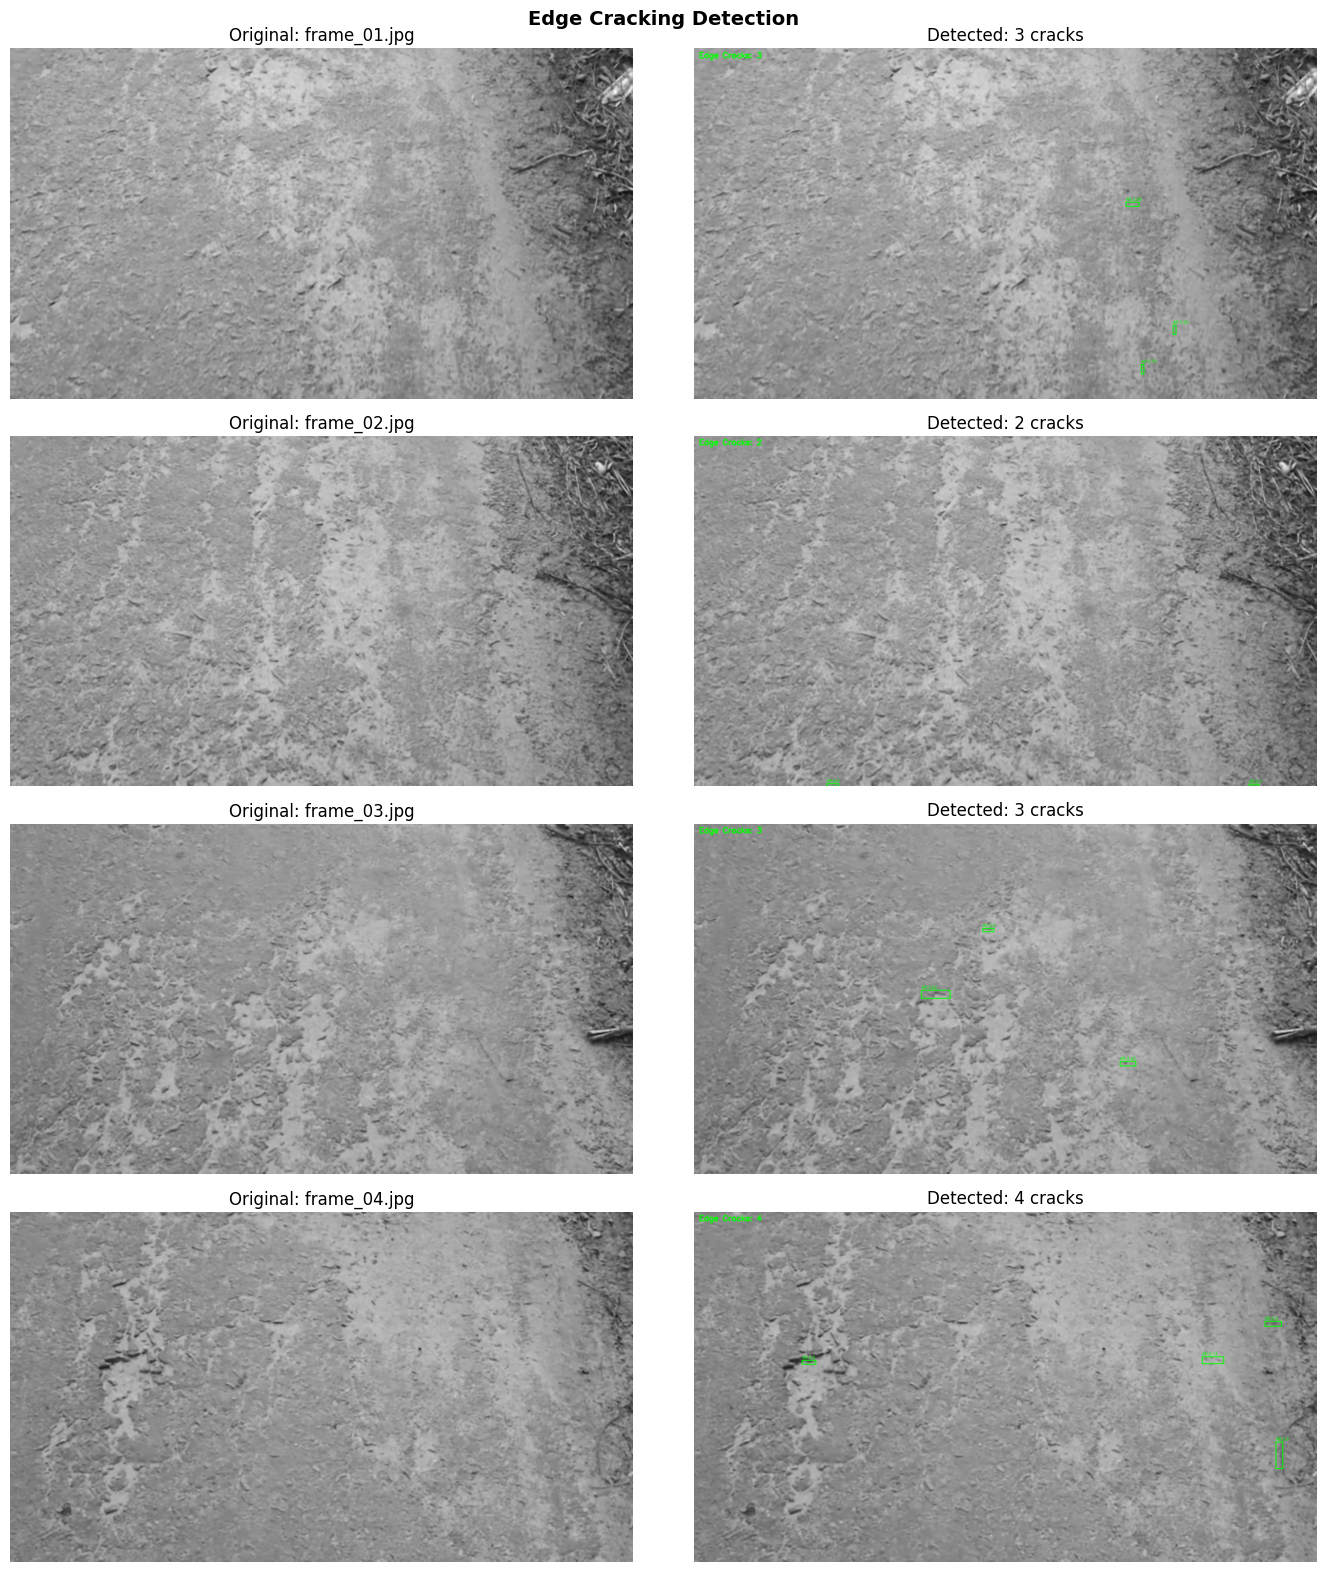

In [260]:
def detect_edge_cracking_parts(img_bgr):
    """
    Detects road surface cracks.
    Strategy: cracks are DARK, THIN, ELONGATED features on a lighter road surface.
    Uses black-hat morphology to isolate dark linear features, combined with
    Canny edges, then applies strict shape + darkness filters.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # ── Focus on road surface (bottom 70%) ──────────────────────────
    road_start = int(h * 0.30)
    gray_road  = gray[road_start:, :]
    rh, rw     = gray_road.shape

    # ── Step 1: CLAHE to normalise illumination ──────────────────────
    clahe      = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced   = clahe.apply(gray_road)

    # ── Step 2: Black-hat transform — highlights dark features on light bg ──
    # Kernel size controls the maximum width of features we detect
    bh_kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    blackhat   = cv2.morphologyEx(enhanced, cv2.MORPH_BLACKHAT, bh_kernel)

    # ── Step 3: Threshold the black-hat result ───────────────────────
    _, bh_mask = cv2.threshold(blackhat, 20, 255, cv2.THRESH_BINARY)

    # ── Step 4: Canny edges on a bilateral-filtered copy ────────────
    bilateral  = cv2.bilateralFilter(enhanced, 9, 50, 50)
    edges      = cv2.Canny(bilateral, 50, 130)

    # ── Step 5: Combine black-hat mask + edges (both must agree) ────
    combined   = cv2.bitwise_and(bh_mask, edges)

    # ── Step 6: Moderate dilation to connect crack fragments ─────────
    link_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    combined    = cv2.dilate(combined, link_kernel, iterations=2)

    # ── Step 7: Small open to remove isolated noise pixels ──────────
    clean_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    crack_mask   = cv2.morphologyEx(combined, cv2.MORPH_OPEN, clean_kernel, iterations=1)

    # ── Step 8: Find and filter contours ────────────────────────────
    contours, _ = cv2.findContours(crack_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    img_area   = rh * rw
    detections = []

    for cnt in contours:
        area = cv2.contourArea(cnt)

        # Size: ignore tiny noise and huge shadow blobs
        if area < 100 or area > 0.15 * img_area:
            continue

        x, y, bw, bh_ = cv2.boundingRect(cnt)
        if bh_ == 0 or bw == 0:
            continue

        # ── Elongation: cracks are linear, not blobby ────────────────
        aspect_ratio = max(bw, bh_) / float(min(bw, bh_))
        if aspect_ratio < 3.0:
            continue

        # ── Solidity: cracks fill their hull reasonably ───────────────
        hull      = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        if hull_area == 0:
            continue
        solidity  = area / float(hull_area)
        if solidity < 0.35:
            continue

        # ── Complexity: cracks have some bends but aren't circular ───
        arc_length = cv2.arcLength(cnt, False)
        if arc_length == 0:
            continue
        approx     = cv2.approxPolyDP(cnt, 0.02 * arc_length, False)
        if len(approx) > 18:
            continue

        # ── Darkness check: the region must be genuinely darker ───────
        # Compare mean of the bbox interior vs a border ring around it
        pad    = 8
        y1_in, y2_in = y, y + bh_
        x1_in, x2_in = x, x + bw
        y1_out = max(0,  y1_in - pad)
        y2_out = min(rh, y2_in + pad)
        x1_out = max(0,  x1_in - pad)
        x2_out = min(rw, x2_in + pad)

        inner_mean = np.mean(enhanced[y1_in:y2_in, x1_in:x2_in])
        outer_mask = np.zeros_like(enhanced[y1_out:y2_out, x1_out:x2_out])
        outer_mask[:pad, :]  = 1   # top border
        outer_mask[-pad:, :] = 1   # bottom border
        outer_mask[:, :pad]  = 1   # left border
        outer_mask[:, -pad:] = 1   # right border
        outer_region = enhanced[y1_out:y2_out, x1_out:x2_out]
        outer_mean   = np.mean(outer_region[outer_mask == 1]) if outer_mask.any() else 255

        # Crack must be at least 10 intensity levels darker than surroundings
        if outer_mean - inner_mean < 10:
            continue

        # ── Local contrast: reject uniform shadow areas ────────────────
        region_std = np.std(enhanced[y1_in:y2_in, x1_in:x2_in])
        if region_std < 8:
            continue

        detections.append({
            "bbox":   (x, y + road_start, bw, bh_),  # back to full-image coords
            "center": (x + bw // 2, y + bh_ // 2),
            "area":   area,
            "aspect": round(aspect_ratio, 2),
        })

    # ── Step 9: Non-maximum suppression — remove overlapping boxes ───
    def iou(a, b):
        ax, ay, aw, ah = a
        bx, by, bw2, bh2 = b
        ix = max(0, min(ax+aw, bx+bw2) - max(ax, bx))
        iy = max(0, min(ay+ah, by+bh2) - max(ay, by))
        inter = ix * iy
        union = aw*ah + bw2*bh2 - inter
        return inter / union if union > 0 else 0

    detections = sorted(detections, key=lambda d: d["area"], reverse=True)
    kept = []
    for det in detections:
        if all(iou(det["bbox"], k["bbox"]) < 0.4 for k in kept):
            kept.append(det)

    return kept, crack_mask


# ── Runner — process all filtered frames ─────────────────────────────────────
input_folder_edge  = filtered_folder
marked_folder_edge = "detectedEdgeCrackingFinal"
os.makedirs(marked_folder_edge, exist_ok=True)

files_edge = sorted([
    f for f in os.listdir(input_folder_edge)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
])

summary_edge = []
preview_edge = []
crack_color  = (0, 255, 0)   # GREEN

for fname in files_edge:
    src_path = os.path.join(input_folder_edge, fname)
    dst_path = os.path.join(marked_folder_edge, fname)

    # filtered_folder contains grayscale images → convert to BGR for drawing
    gray_img = cv2.imread(src_path, cv2.IMREAD_GRAYSCALE)
    if gray_img is None:
        continue
    img_bgr  = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2BGR)

    detections, _ = detect_edge_cracking_parts(img_bgr)
    marked         = img_bgr.copy()

    for d in detections:
        x, y, bw, bh_ = d["bbox"]
        cv2.rectangle(marked, (x, y), (x + bw, y + bh_), crack_color, 2)
        cv2.putText(marked, f"AR:{d['aspect']}",
                    (x, max(0, y - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, crack_color, 1, cv2.LINE_AA)

    label = f"Edge Cracks: {len(detections)}"
    cv2.putText(marked, label, (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, crack_color, 2, cv2.LINE_AA)

    cv2.imwrite(dst_path, marked)
    summary_edge.append({"file": fname, "detected_cracks": len(detections)})

    if len(preview_edge) < 4:
        preview_edge.append((img_bgr, marked, fname, len(detections)))

# ── Print results ─────────────────────────────────────────────────────────────
print(f"✓ Edge Cracking Detection Complete")
print(f"  Processed  : {len(summary_edge)} images")
print(f"  With cracks: {sum(1 for s in summary_edge if s['detected_cracks'] > 0)}")
print(f"  Total boxes: {sum(s['detected_cracks'] for s in summary_edge)}")
print(f"  Output     : {marked_folder_edge}/")

# ── Preview plot ──────────────────────────────────────────────────────────────
if preview_edge:
    fig, axes = plt.subplots(len(preview_edge), 2, figsize=(14, 4 * len(preview_edge)))
    if len(preview_edge) == 1:
        axes = [axes]
    for i, (orig, marked, fname, n) in enumerate(preview_edge):
        axes[i][0].imshow(cv2.cvtColor(orig,   cv2.COLOR_BGR2RGB))
        axes[i][0].set_title(f"Original: {fname}"); axes[i][0].axis("off")
        axes[i][1].imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
        axes[i][1].set_title(f"Detected: {n} cracks"); axes[i][1].axis("off")
    plt.suptitle("Edge Cracking Detection", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 4. Pedestrian Crossing Detection
Detect zebra crossing markings and lane markings (marks with blue borders)

✓ Pedestrian Crossing Detection Complete (V7 - Simple bright stripe detection)
  Processed: 30 images
  With markings: 27
  Output: detectedCrossingFinal/


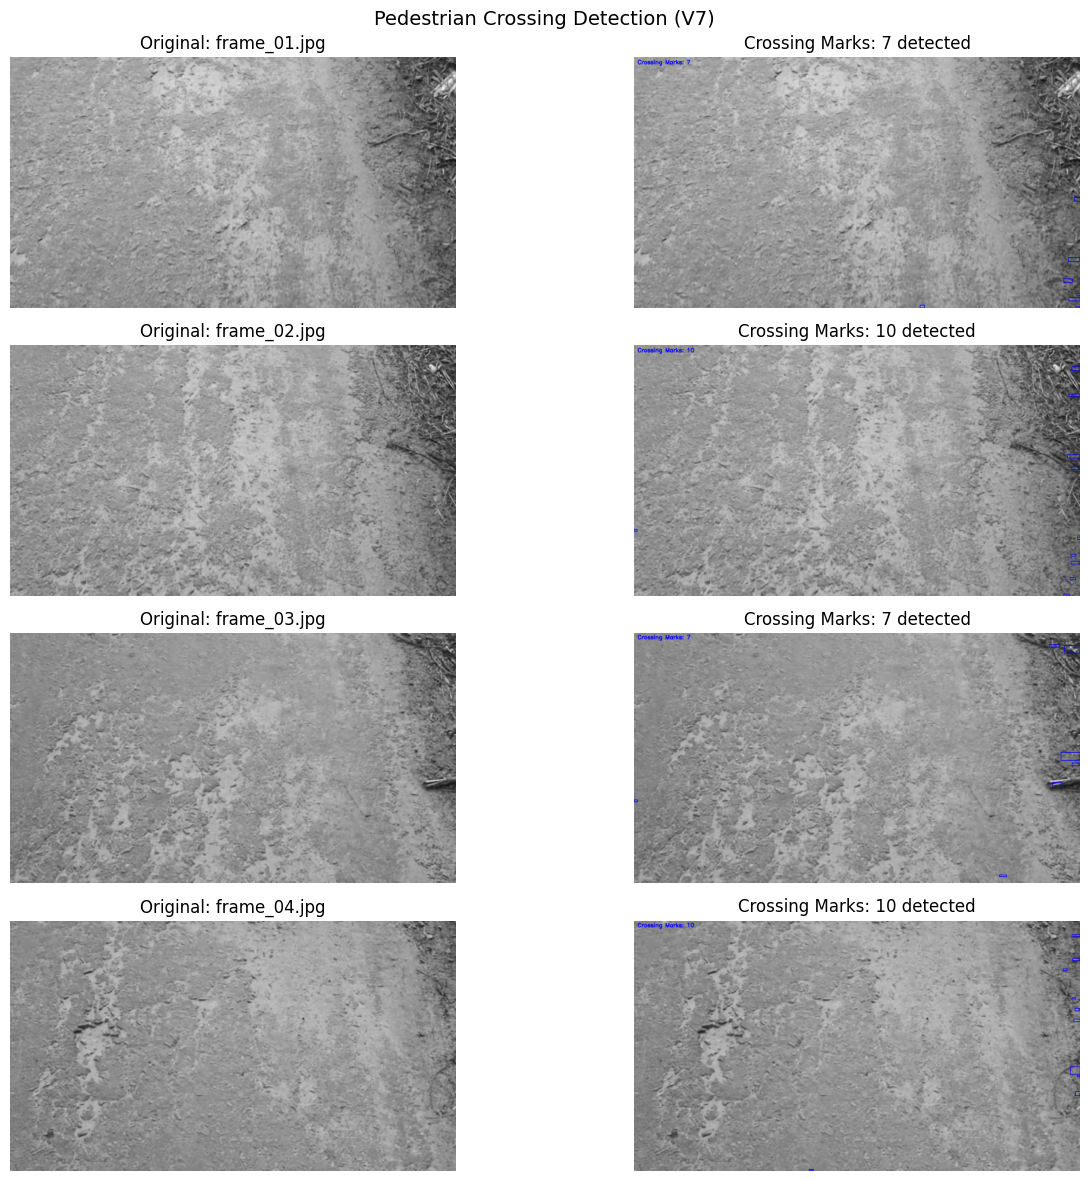

In [252]:
def detect_pedestrian_crossing(img_bgr):
    """Detects zebra crossing by finding bright horizontal stripe regions"""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    
    road_start = int(h * 0.05)
    gray_road = gray[road_start:, :]
    
    # Strong contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=10.0, tileGridSize=(6, 6))
    gray_enhanced = clahe.apply(gray_road)
    
    # Detect bright regions at multiple levels
    _, bright_100 = cv2.threshold(gray_enhanced, 100, 255, cv2.THRESH_BINARY)
    _, bright_110 = cv2.threshold(gray_enhanced, 110, 255, cv2.THRESH_BINARY)
    _, bright_120 = cv2.threshold(gray_enhanced, 120, 255, cv2.THRESH_BINARY)
    
    # Combine all brightness levels
    bright_combined = cv2.bitwise_or(bright_100, bright_110)
    bright_combined = cv2.bitwise_or(bright_combined, bright_120)
    
    # Very light morphology - just close small gaps horizontally
    kernel_close_h = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 1))
    stripe_mask = cv2.morphologyEx(bright_combined, cv2.MORPH_CLOSE, kernel_close_h, iterations=1)
    
    # Minimal noise removal
    kernel_clean = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    stripe_mask = cv2.morphologyEx(stripe_mask, cv2.MORPH_OPEN, kernel_clean, iterations=1)
    
    # Find contours
    contours, _ = cv2.findContours(stripe_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    img_area = gray_road.shape[0] * gray_road.shape[1]
    detections = []
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        x, y, bw, bh = cv2.boundingRect(cnt)
        
        if bh == 0 or bw == 0:
            continue
        
        # Relax all constraints
        if area < 50:  # Minimum size for real marking
            continue
        if area > 0.5 * img_area:  # Maximum - avoid full image
            continue
        
        # Width should be larger than height (horizontal stripes)
        if bw < bh:
            continue
        
        # Expect reasonable solidity
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        if hull_area == 0:
            continue
        solidity = area / float(hull_area)
        
        if solidity < 0.3:  # Allow irregular shapes
            continue
        
        detections.append({
            "bbox": (x, y+road_start, bw, bh),
            "center": (x + bw//2, y + bh//2),
            "area": area,
        })
    
    # Filter extreme duplicates (very close centers)
    detections = sorted(detections, key=lambda d: d["area"], reverse=True)
    filtered = []
    
    for d in detections:
        is_dup = False
        x1, y1, w1, h1 = d["bbox"]
        
        for f in filtered:
            x2, y2, w2, h2 = f["bbox"]
            # Only merge if centers are extremely close
            if abs(x1-(x2+w2//2)) < 20 and abs(y1-(y2+h2//2)) < 20:
                is_dup = True
                break
        
        if not is_dup:
            filtered.append(d)
    
    return filtered

# Process all filtered frames for pedestrian crossing
input_folder_cross = filtered_folder
marked_folder_cross = "detectedCrossingFinal"
os.makedirs(marked_folder_cross, exist_ok=True)

files_cross = sorted([f for f in os.listdir(input_folder_cross) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))])

summary_cross = []
preview_cross = []

for fname in files_cross:
    src_path = os.path.join(input_folder_cross, fname)
    dst_path = os.path.join(marked_folder_cross, fname)
    
    img = cv2.imread(src_path)
    if img is None:
        continue
    
    detections = detect_pedestrian_crossing(img)
    marked = img.copy()
    
    cross_color = (255, 0, 0)  # Blue
    
    for d in detections:
        x, y, bw, bh = d["bbox"]
        cv2.rectangle(marked, (x, y), (x + bw, y + bh), cross_color, 2)
    
    label = f"Crossing Marks: {len(detections)}"
    cv2.putText(marked, label, (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, cross_color, 2, cv2.LINE_AA)
    
    cv2.imwrite(dst_path, marked)
    
    summary_cross.append({"file": fname, "detected_markings": len(detections)})
    
    if len(preview_cross) < 4:
        preview_cross.append((img, marked, fname, len(detections)))

print(f"✓ Pedestrian Crossing Detection Complete (V7 - Simple bright stripe detection)")
print(f"  Processed: {len(summary_cross)} images")
print(f"  With markings: {sum(1 for s in summary_cross if s['detected_markings'] > 0)}")
print(f"  Output: {marked_folder_cross}/")

if len(preview_cross) > 0:
    plt.figure(figsize=(14, 12))
    for i, (orig, marked, fname, n) in enumerate(preview_cross, start=1):
        plt.subplot(len(preview_cross), 2, 2 * i - 1)
        plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {fname}")
        plt.axis("off")
        
        plt.subplot(len(preview_cross), 2, 2 * i)
        plt.imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
        plt.title(f"Crossing Marks: {n} detected")
        plt.axis("off")
    
    plt.suptitle("Pedestrian Crossing Detection (V7)", fontsize=14)
    plt.tight_layout()
    plt.show()

# 5. Ravelling Detection
Detect road surface deterioration and aggregate loss (marks with red borders)

✓ Ravelling Detection Complete
  Processed      : 30 images
  With ravelling : 19
  Total detections: 220
  Output         : detectedRavellingFinal/


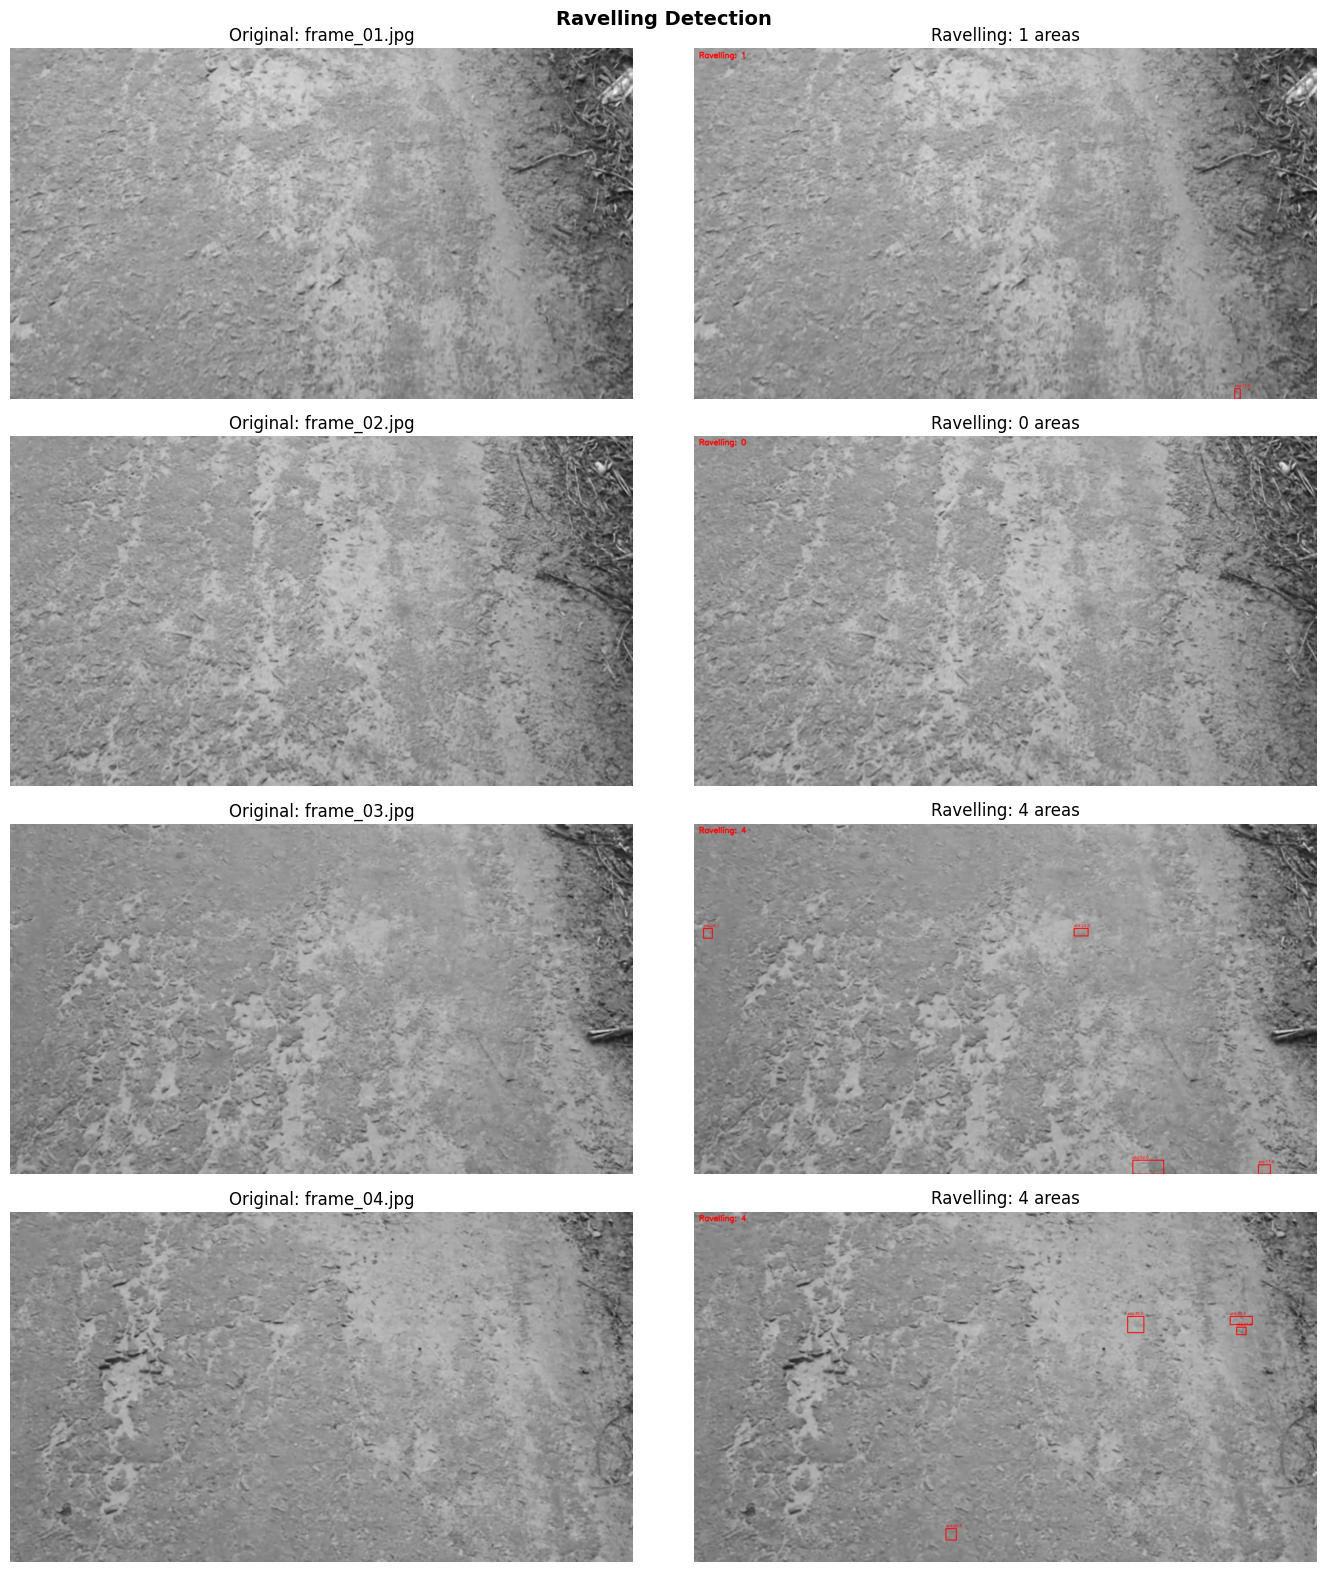

In [261]:
def detect_ravelling_parts(img_bgr):
    """
    Ravelling = rough, pitted road surface where aggregate separates from binder.
    Key signal: HIGH LOCAL TEXTURE VARIANCE with mixed bright/dark pixels.
    Strategy: compute per-pixel local std-dev map, threshold it, then filter
    contours by shape and regional statistics.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # ── Focus on road surface (bottom 70%) ──────────────────────────
    road_start = int(h * 0.30)
    gray_road  = gray[road_start:, :]
    rh, rw     = gray_road.shape

    # ── Step 1: CLAHE to normalise illumination ──────────────────────
    clahe    = cv2.createCLAHE(clipLimit=3.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray_road)

    # ── Step 2: Local std-dev map ─────────────────────────────────────
    # local_std = sqrt(E[X²] - E[X]²)  computed efficiently with box filters
    enh_f    = enhanced.astype(np.float32)
    ksize    = (15, 15)
    local_mean   = cv2.blur(enh_f, ksize)
    local_mean_sq = cv2.blur(enh_f ** 2, ksize)
    local_var    = np.maximum(local_mean_sq - local_mean ** 2, 0)
    local_std    = np.sqrt(local_var)                          # float32

    # ── Step 3: Threshold — keep high-texture regions ────────────────
    # Ravelling std-dev is typically > 18 on a 0-255 scale
    texture_mask = (local_std > 18).astype(np.uint8) * 255

    # ── Step 4: Top-hat — bright exposed aggregate spots ─────────────
    th_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    tophat    = cv2.morphologyEx(enhanced, cv2.MORPH_TOPHAT, th_kernel)
    _, agg_mask = cv2.threshold(tophat, 18, 255, cv2.THRESH_BINARY)

    # ── Step 5: Black-hat — dark pits / gaps between aggregate ───────
    bh_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    blackhat  = cv2.morphologyEx(enhanced, cv2.MORPH_BLACKHAT, bh_kernel)
    _, pit_mask = cv2.threshold(blackhat, 18, 255, cv2.THRESH_BINARY)

    # ── Step 6: Require texture AND (bright aggregate OR dark pits) ──
    # This is AND logic — reduces false positives dramatically vs OR
    signal_mask = cv2.bitwise_or(agg_mask, pit_mask)
    combined    = cv2.bitwise_and(texture_mask, signal_mask)

    # ── Step 7: Morphological cleanup ────────────────────────────────
    close_k  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, close_k, iterations=2)
    open_k   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN,  open_k,  iterations=1)

    # ── Step 8: Find and filter contours ────────────────────────────
    contours, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    img_area   = rh * rw
    detections = []

    for cnt in contours:
        area = cv2.contourArea(cnt)

        # Size: small noise → skip; huge shadow blobs → skip
        if area < 300 or area > 0.20 * img_area:
            continue

        x, y, bw, bh_ = cv2.boundingRect(cnt)
        if bh_ == 0 or bw == 0:
            continue

        # Ravelling patches are patchy, NOT highly elongated
        aspect_ratio = max(bw, bh_) / float(min(bw, bh_))
        if aspect_ratio > 5.0:
            continue

        # Solidity: ravelling regions are irregular but not hollow
        hull      = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        if hull_area == 0:
            continue
        solidity  = area / float(hull_area)
        if solidity < 0.30:
            continue

        # ── Region statistics ─────────────────────────────────────────
        region     = enhanced[y:y+bh_, x:x+bw]
        if region.size == 0:
            continue

        region_std  = np.std(region)
        region_mean = np.mean(region)

        # Must have genuine texture variance (key ravelling signal)
        if region_std < 15:
            continue

        # Reject very bright areas (specular reflections, white markings)
        if region_mean > 210:
            continue

        # Reject very dark uniform areas (deep shadows)
        if region_mean < 40:
            continue

        # Confirm it's not just a uniform shadow:
        # ravelling has both light and dark pixels mixed
        bright_frac = np.mean(region > region_mean + 15)
        dark_frac   = np.mean(region < region_mean - 15)
        if bright_frac < 0.10 or dark_frac < 0.10:
            continue

        detections.append({
            "bbox":   (x, y + road_start, bw, bh_),
            "center": (x + bw // 2, y + bh_ // 2),
            "area":   area,
            "std":    round(region_std, 1),
        })

    # ── Step 9: IoU-based NMS ────────────────────────────────────────
    def iou(a, b):
        ax, ay, aw, ah = a;  bx, by, bw2, bh2 = b
        ix = max(0, min(ax+aw, bx+bw2) - max(ax, bx))
        iy = max(0, min(ay+ah, by+bh2) - max(ay, by))
        inter = ix * iy
        union = aw*ah + bw2*bh2 - inter
        return inter / union if union > 0 else 0

    detections = sorted(detections, key=lambda d: d["area"], reverse=True)
    kept = []
    for det in detections:
        if all(iou(det["bbox"], k["bbox"]) < 0.4 for k in kept):
            kept.append(det)

    return kept, combined


# ── Runner ────────────────────────────────────────────────────────────────────
input_folder_rav  = filtered_folder
marked_folder_rav = "detectedRavellingFinal"
os.makedirs(marked_folder_rav, exist_ok=True)

files_rav = sorted([
    f for f in os.listdir(input_folder_rav)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
])

summary_rav = []
preview_rav = []
rav_color   = (0, 0, 255)   # RED

for fname in files_rav:
    src_path = os.path.join(input_folder_rav, fname)
    dst_path = os.path.join(marked_folder_rav, fname)

    gray_img = cv2.imread(src_path, cv2.IMREAD_GRAYSCALE)
    if gray_img is None:
        continue
    img_bgr = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2BGR)

    detections, _ = detect_ravelling_parts(img_bgr)
    marked = img_bgr.copy()

    for d in detections:
        x, y, bw, bh_ = d["bbox"]
        cv2.rectangle(marked, (x, y), (x+bw, y+bh_), rav_color, 2)
        cv2.putText(marked, f"std:{d['std']}",
                    (x, max(0, y-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, rav_color, 1, cv2.LINE_AA)

    cv2.putText(marked, f"Ravelling: {len(detections)}", (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, rav_color, 2, cv2.LINE_AA)
    cv2.imwrite(dst_path, marked)

    summary_rav.append({"file": fname, "detected_ravelling": len(detections)})
    if len(preview_rav) < 4:
        preview_rav.append((img_bgr, marked, fname, len(detections)))

print(f"✓ Ravelling Detection Complete")
print(f"  Processed      : {len(summary_rav)} images")
print(f"  With ravelling : {sum(1 for s in summary_rav if s['detected_ravelling'] > 0)}")
print(f"  Total detections: {sum(s['detected_ravelling'] for s in summary_rav)}")
print(f"  Output         : {marked_folder_rav}/")

if preview_rav:
    fig, axes = plt.subplots(len(preview_rav), 2, figsize=(14, 4 * len(preview_rav)))
    if len(preview_rav) == 1: axes = [axes]
    for i, (orig, marked, fname, n) in enumerate(preview_rav):
        axes[i][0].imshow(cv2.cvtColor(orig,   cv2.COLOR_BGR2RGB))
        axes[i][0].set_title(f"Original: {fname}"); axes[i][0].axis("off")
        axes[i][1].imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
        axes[i][1].set_title(f"Ravelling: {n} areas"); axes[i][1].axis("off")
    plt.suptitle("Ravelling Detection", fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

# 6. Pothole Detection
Detect road surface depression defects and pits (marks with cyan borders)

✓ Pothole Detection Complete
  Processed        : 30 images
  With potholes    : 21
  Total detections : 396
  Output           : detectedPotholeFinal/


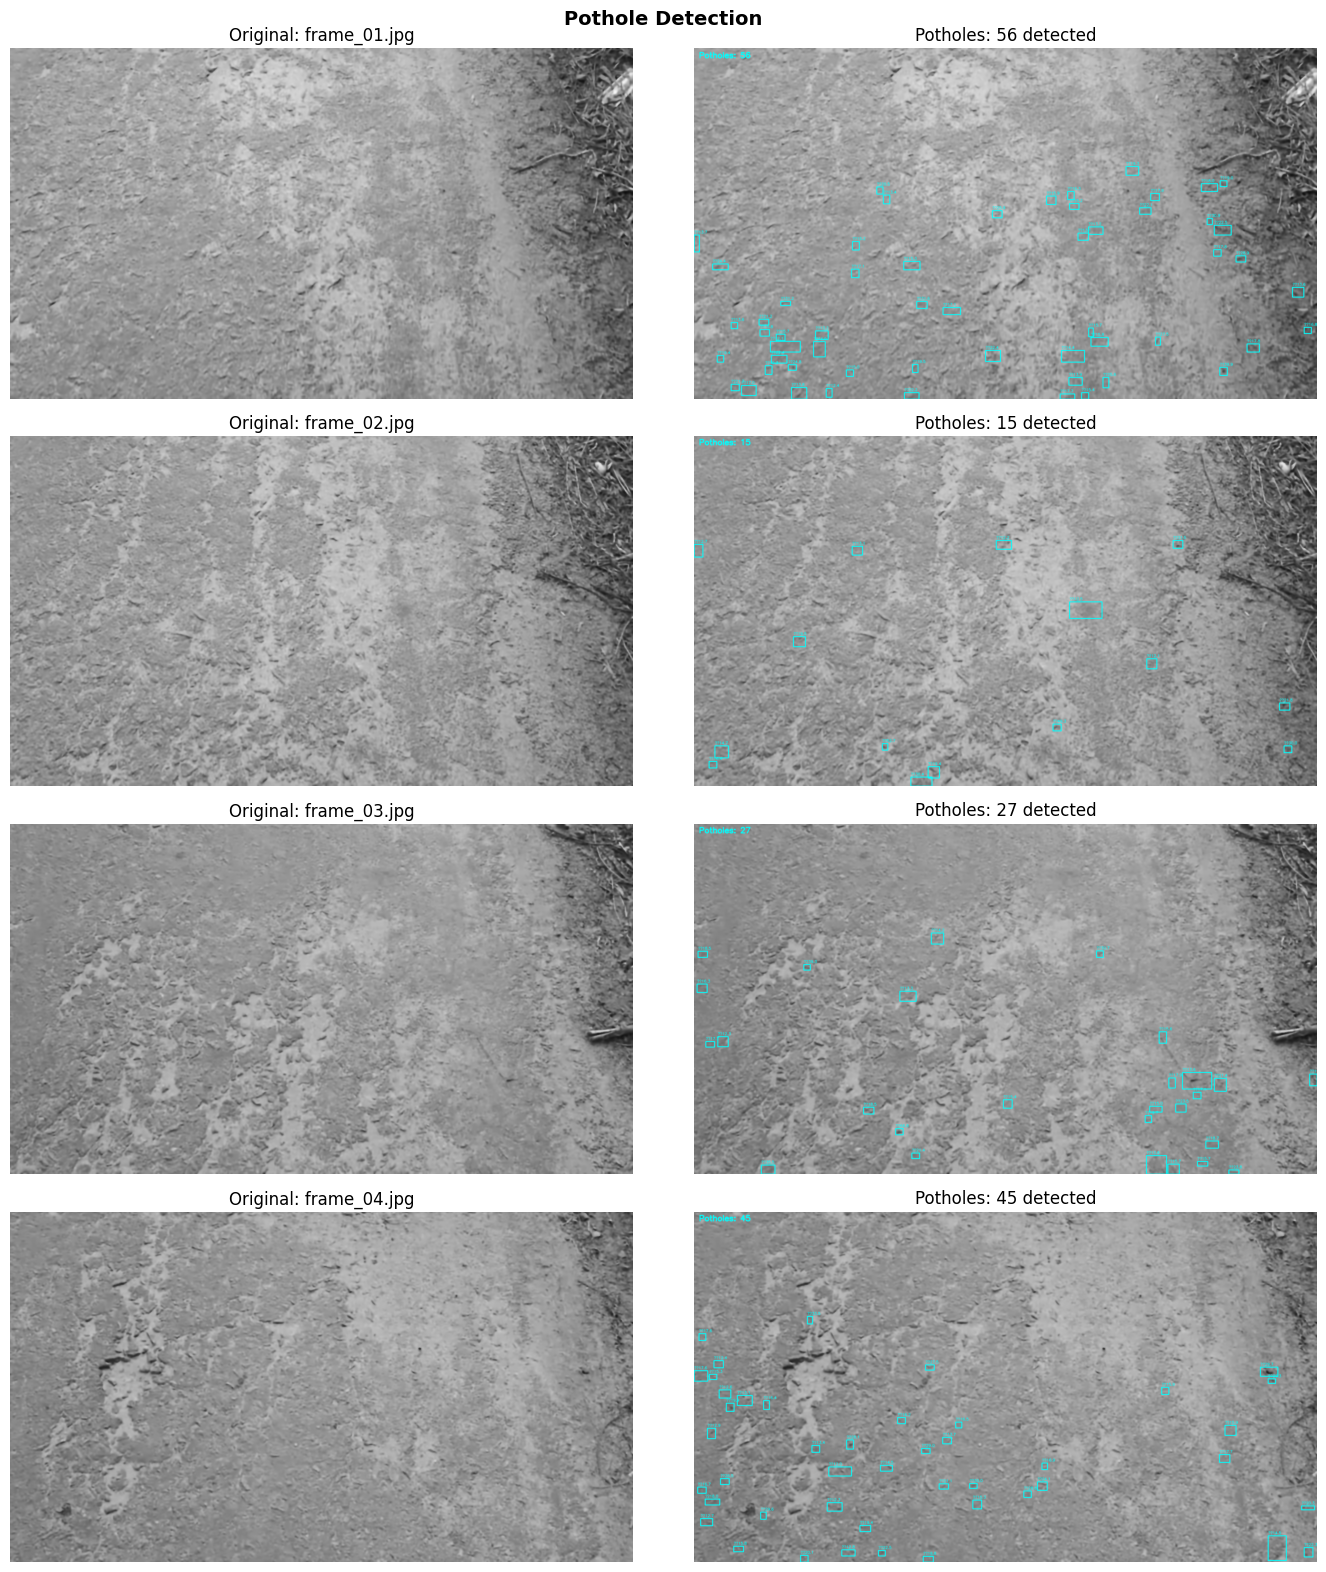

In [262]:
def detect_pothole_parts(img_bgr):
    """
    Potholes = compact dark depressions with rough interior texture.
    Key insight: a pothole is darker than its LOCAL surroundings,
    not just globally dark. Using local deviation instead of a global
    percentile threshold handles varying road brightness correctly.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # ── Focus on road surface (bottom 70%) ──────────────────────────
    road_start = int(h * 0.30)
    gray_road  = gray[road_start:, :]
    rh, rw     = gray_road.shape

    # ── Step 1: CLAHE ────────────────────────────────────────────────
    clahe    = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray_road)

    # ── Step 2: Local deviation — find regions darker than neighbours ─
    # Local mean over a large neighbourhood represents the "road baseline"
    enh_f      = enhanced.astype(np.float32)
    local_mean = cv2.blur(enh_f, (45, 45))          # large window = local baseline
    deviation  = local_mean - enh_f                  # positive = darker than surroundings

    # Threshold: must be at least 18 intensity levels below local mean
    dark_mask  = (deviation > 18).astype(np.uint8) * 255

    # ── Step 3: Exclude extreme shadows (deviation too large) ────────
    # Shadow edges can be very sharp; cap maximum deviation
    shadow_mask = (deviation > 80).astype(np.uint8) * 255
    dark_mask   = cv2.bitwise_and(dark_mask, cv2.bitwise_not(shadow_mask))

    # ── Step 4: Morphological cleanup ────────────────────────────────
    kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    dark_mask = cv2.morphologyEx(dark_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    dark_mask = cv2.morphologyEx(dark_mask, cv2.MORPH_OPEN,  kernel, iterations=1)

    # ── Step 5: Find and filter contours ────────────────────────────
    contours, _ = cv2.findContours(dark_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    img_area   = rh * rw
    detections = []

    for cnt in contours:
        area = cv2.contourArea(cnt)

        # Size: pothole must be meaningful but not huge shadow
        if area < 200 or area > 0.18 * img_area:
            continue

        x, y, bw, bh_ = cv2.boundingRect(cnt)
        if bh_ == 0 or bw == 0:
            continue

        # Potholes are compact — not very elongated
        aspect_ratio = max(bw, bh_) / float(min(bw, bh_))
        if aspect_ratio > 3.5:
            continue

        # Solidity: potholes are roughly convex
        hull      = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        if hull_area == 0:
            continue
        solidity  = area / float(hull_area)
        if solidity < 0.35:
            continue

        # ── Region statistics ─────────────────────────────────────────
        region     = enhanced[y:y+bh_, x:x+bw]
        if region.size == 0:
            continue

        region_std  = np.std(region)
        region_mean = np.mean(region)

        # Must have some internal texture (rules out uniform flat shadows)
        if region_std < 10:
            continue

        # Must be genuinely dark relative to overall road brightness
        road_mean = np.mean(enhanced)
        if region_mean > road_mean - 15:
            continue

        # Reject very bright interiors (reflections, white markings)
        if region_mean > 160:
            continue

        # Confirm local contrast: pothole edge should show a meaningful
        # brightness step vs its immediate surroundings
        pad       = 12
        y1o = max(0,  y - pad);  y2o = min(rh, y + bh_ + pad)
        x1o = max(0,  x - pad);  x2o = min(rw, x + bw  + pad)
        outer_region = enhanced[y1o:y2o, x1o:x2o]
        outer_mean   = np.mean(outer_region)
        if outer_mean - region_mean < 12:   # not dark enough vs surroundings
            continue

        detections.append({
            "bbox":     (x, y + road_start, bw, bh_),
            "area":     area,
            "darkness": round(float(outer_mean - region_mean), 1),
            "solidity": round(solidity, 2),
        })

    # ── Step 6: IoU-based NMS ─────────────────────────────────────────
    def iou(a, b):
        ax, ay, aw, ah = a;  bx, by, bw2, bh2 = b
        ix = max(0, min(ax+aw, bx+bw2) - max(ax, bx))
        iy = max(0, min(ay+ah, by+bh2) - max(ay, by))
        inter = ix * iy
        union = aw*ah + bw2*bh2 - inter
        return inter / union if union > 0 else 0

    detections = sorted(detections, key=lambda d: d["darkness"], reverse=True)
    kept = []
    for det in detections:
        if all(iou(det["bbox"], k["bbox"]) < 0.4 for k in kept):
            kept.append(det)

    return kept


# ── Runner ────────────────────────────────────────────────────────────────────
input_folder_pot  = filtered_folder
marked_folder_pot = "detectedPotholeFinal"
os.makedirs(marked_folder_pot, exist_ok=True)

files_pot = sorted([
    f for f in os.listdir(input_folder_pot)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
])

summary_pot = []
preview_pot = []
pot_color   = (255, 255, 0)   # CYAN

for fname in files_pot:
    src_path = os.path.join(input_folder_pot, fname)
    dst_path = os.path.join(marked_folder_pot, fname)

    gray_img = cv2.imread(src_path, cv2.IMREAD_GRAYSCALE)
    if gray_img is None:
        continue
    img_bgr = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2BGR)

    detections = detect_pothole_parts(img_bgr)
    marked     = img_bgr.copy()

    for d in detections:
        x, y, bw, bh_ = d["bbox"]
        cv2.rectangle(marked, (x, y), (x+bw, y+bh_), pot_color, 2)
        cv2.putText(marked, f"Δ{d['darkness']}",
                    (x, max(0, y-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, pot_color, 1, cv2.LINE_AA)

    cv2.putText(marked, f"Potholes: {len(detections)}", (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, pot_color, 2, cv2.LINE_AA)
    cv2.imwrite(dst_path, marked)

    summary_pot.append({"file": fname, "detected_potholes": len(detections)})
    if len(preview_pot) < 4:
        preview_pot.append((img_bgr, marked, fname, len(detections)))

print(f"✓ Pothole Detection Complete")
print(f"  Processed        : {len(summary_pot)} images")
print(f"  With potholes    : {sum(1 for s in summary_pot if s['detected_potholes'] > 0)}")
print(f"  Total detections : {sum(s['detected_potholes'] for s in summary_pot)}")
print(f"  Output           : {marked_folder_pot}/")

if preview_pot:
    fig, axes = plt.subplots(len(preview_pot), 2, figsize=(14, 4 * len(preview_pot)))
    if len(preview_pot) == 1: axes = [axes]
    for i, (orig, marked, fname, n) in enumerate(preview_pot):
        axes[i][0].imshow(cv2.cvtColor(orig,   cv2.COLOR_BGR2RGB))
        axes[i][0].set_title(f"Original: {fname}"); axes[i][0].axis("off")
        axes[i][1].imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
        axes[i][1].set_title(f"Potholes: {n} detected"); axes[i][1].axis("off")
    plt.suptitle("Pothole Detection", fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

## Pipeline Summary and Statistics

In [255]:
# Debug frame 101 - analyze why zebra crossing isn't detected
frame_101_path = os.path.join(filtered_folder, "frame_101.jpg")
if os.path.exists(frame_101_path):
    img_debug = cv2.imread(frame_101_path)
    gray_debug = cv2.cvtColor(img_debug, cv2.COLOR_BGR2GRAY)
    
    # Analyze the image
    print(f"Frame 101 Analysis:")
    print(f"  Shape: {gray_debug.shape}")
    print(f"  Mean brightness: {np.mean(gray_debug):.2f}")
    print(f"  Min brightness: {np.min(gray_debug)}")
    print(f"  Max brightness: {np.max(gray_debug)}")
    print(f"  Std dev: {np.std(gray_debug):.2f}")
    
    # Check brightness distribution
    hist = cv2.calcHist([gray_debug], [0], None, [256], [0, 256]).flatten()
    print(f"  Pixels > 140: {int(np.sum(hist[140:]))} ({np.sum(hist[140:])/len(gray_debug.flatten())*100:.1f}%)")
    print(f"  Pixels > 160: {int(np.sum(hist[160:]))} ({np.sum(hist[160:])/len(gray_debug.flatten())*100:.1f}%)")
    
    # Check in road area
    h = gray_debug.shape[0]
    road_start = int(h * 0.1)
    gray_road_debug = gray_debug[road_start:, :]
    
    print(f"\n  Road area analysis (from row {road_start}):")
    print(f"    Mean brightness: {np.mean(gray_road_debug):.2f}")
    print(f"    Pixels > 140: {int(np.sum(gray_road_debug > 140))} ({np.sum(gray_road_debug > 140)/gray_road_debug.size*100:.1f}%)")
    print(f"    Pixels > 160: {int(np.sum(gray_road_debug > 160))} ({np.sum(gray_road_debug > 160)/gray_road_debug.size*100:.1f}%)")
    
    # Test CLAHE
    clahe = cv2.createCLAHE(clipLimit=6.0, tileGridSize=(8, 8))
    gray_enhanced_debug = clahe.apply(gray_road_debug)
    
    print(f"\n  After CLAHE enhancement:")
    print(f"    Mean: {np.mean(gray_enhanced_debug):.2f}")
    print(f"    Pixels > 140: {int(np.sum(gray_enhanced_debug > 140))} ({np.sum(gray_enhanced_debug > 140)/gray_enhanced_debug.size*100:.1f}%)")
    
    # Visualize thresholds
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0,0].imshow(cv2.cvtColor(img_debug, cv2.COLOR_BGR2RGB))
    axes[0,0].set_title("Original Frame 101")
    axes[0,0].axis("off")
    
    axes[0,1].imshow(gray_debug, cmap='gray')
    axes[0,1].set_title("Grayscale")
    axes[0,1].axis("off")
    
    axes[0,2].plot(hist, color='black')
    axes[0,2].axvline(x=140, color='red', label='Threshold 140')
    axes[0,2].axvline(x=160, color='blue', label='Threshold 160')
    axes[0,2].set_title("Brightness Histogram")
    axes[0,2].legend()
    axes[0,2].set_xlim([0, 256])
    
    _, thresh_140 = cv2.threshold(gray_road_debug, 140, 255, cv2.THRESH_BINARY)
    axes[1,0].imshow(thresh_140, cmap='gray')
    axes[1,0].set_title("Threshold at 140")
    axes[1,0].axis("off")
    
    _, thresh_160 = cv2.threshold(gray_road_debug, 160, 255, cv2.THRESH_BINARY)
    axes[1,1].imshow(thresh_160, cmap='gray')
    axes[1,1].set_title("Threshold at 160")
    axes[1,1].axis("off")
    
    axes[1,2].imshow(gray_enhanced_debug, cmap='gray')
    axes[1,2].set_title("CLAHE Enhanced")
    axes[1,2].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("Frame 101 not found!")


Frame 101 not found!


In [256]:
# Debug V7 algorithm on frame 101
frame_101_path = os.path.join(filtered_folder, "frame_101.jpg")
if os.path.exists(frame_101_path):
    img_test = cv2.imread(frame_101_path)
    gray_test = cv2.cvtColor(img_test, cv2.COLOR_BGR2GRAY)
    h, w = gray_test.shape
    
    road_start = int(h * 0.05)
    gray_road_test = gray_test[road_start:, :]
    
    clahe = cv2.createCLAHE(clipLimit=10.0, tileGridSize=(6, 6))
    gray_enhanced_test = clahe.apply(gray_road_test)
    
    _, bright_100 = cv2.threshold(gray_enhanced_test, 100, 255, cv2.THRESH_BINARY)
    _, bright_110 = cv2.threshold(gray_enhanced_test, 110, 255, cv2.THRESH_BINARY)
    _, bright_120 = cv2.threshold(gray_enhanced_test, 120, 255, cv2.THRESH_BINARY)
    
    bright_combined = cv2.bitwise_or(bright_100, bright_110)
    bright_combined = cv2.bitwise_or(bright_combined, bright_120)
    
    kernel_close_h = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 1))
    stripe_mask = cv2.morphologyEx(bright_combined, cv2.MORPH_CLOSE, kernel_close_h, iterations=1)
    
    kernel_clean = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    stripe_mask = cv2.morphologyEx(stripe_mask, cv2.MORPH_OPEN, kernel_clean, iterations=1)
    
    print("Frame 101 V7 Debug:")
    print(f"  Bright_100 pixels: {int(np.sum(bright_100 > 0))}")
    print(f"  Combined bright pixels: {int(np.sum(bright_combined > 0))}")
    print(f"  After morphology: {int(np.sum(stripe_mask > 0))}")
    
    contours, _ = cv2.findContours(stripe_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    print(f"  Total contours: {len(contours)}")
    
    img_area = gray_road_test.shape[0] * gray_road_test.shape[1]
    detections_v7 = []
    
    for idx, cnt in enumerate(contours):
        area = cv2.contourArea(cnt)
        x, y, bw, bh = cv2.boundingRect(cnt)
        
        if bh == 0 or bw == 0:
            print(f"    Contour {idx}: SKIP - zero dimension")
            continue
        
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        solidity = area / float(hull_area) if hull_area > 0 else 0
        
        print(f"    Contour {idx}: area={area:.0f}, box=({x},{y},{bw}x{bh}), w>h={bw>bh}, solidity={solidity:.3f}")
        
        if area < 50:
            print(f"      SKIP - area too small")
            continue
        if area > 0.5 * img_area:
            print(f"      SKIP - area too large ({area:.0f} > {0.5*img_area:.0f})")
            continue
        if bw < bh:
            print(f"      SKIP - height > width")
            continue
        if solidity < 0.3:
            print(f"      SKIP - solidity too low")
            continue
        
        print(f"      ACCEPTED!")
        detections_v7.append((x, y, bw, bh))
    
    print(f"\n  Final detections: {len(detections_v7)}")


In [257]:
# Check which frames have zebra crossing detections (in the 48 that work)
detected_frames = [s['file'] for s in summary_cross if s['detected_markings'] > 0]
print(f"Frames with crossing detections: {len(detected_frames)}")
print("Sample frames:", detected_frames[:10])

# Check frame numbering - extract just the numbers
frame_nums = []
for fname in detected_frames:
    try:
        num = int(fname.replace('frame_', '').replace('.jpg', ''))
        frame_nums.append(num)
    except:
        pass

if frame_nums:
    frame_nums.sort()
    print(f"Frame numbers detected: {frame_nums[:15]}...")
    print(f"Frame 101 in list? {101 in frame_nums}")


Frames with crossing detections: 27
Sample frames: ['frame_01.jpg', 'frame_02.jpg', 'frame_03.jpg', 'frame_04.jpg', 'frame_05.jpg', 'frame_06.jpg', 'frame_07.jpg', 'frame_08.jpg', 'frame_09.jpg', 'frame_10.jpg']
Frame numbers detected: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]...
Frame 101 in list? False


In [258]:
print("=" * 70)
print("COMPLETE PIPELINE SUMMARY")
print("=" * 70)

print("\n✓ VIDEO PROCESSING COMPLETED")
print(f"  Video Path    : {video_path}")
print(f"  Extracted Frames: {extracted_count}")
print(f"  Frame Size    : 640x480")
print(f"  Output Folder : {extracted_30_frames_folder}")

print("\n✓ DEGRADATION ANALYSIS")
print(f"  Sample Size           : {len(df_report)}")
print(f"  Gaussian-affected     : {df_report['Gaussian'].eq('✓').sum()} frames")
print(f"  Salt&Pepper-affected  : {df_report['Salt&Pepper'].eq('✓').sum()} frames")
print(f"  Speckle-affected      : {df_report['Speckle'].eq('✓').sum()} frames")
print(f"  Uniform-affected      : {df_report['Uniform'].eq('✓').sum()} frames")

print("\n✓ FILTERED FRAMES")
print(f"  Total Filtered: {len(filtered_images)}")
print(f"  Output Folder : {filtered_folder}")

print("\n" + "=" * 70)
print("DEFECT DETECTION RESULTS")
print("=" * 70)

print("\n1. EDGE CRACKING DETECTION")
total_cracks = sum(s['detected_cracks'] for s in summary_edge)
frames_with_cracks = sum(1 for s in summary_edge if s['detected_cracks'] > 0)
print(f"   Total Detections : {total_cracks}")
print(f"   Frames with Cracks: {frames_with_cracks}")
print(f"   Output Folder    : {marked_folder_edge}/")
print(f"   Color Marker     : GREEN")

print("\n2. PEDESTRIAN CROSSING DETECTION")
total_markings = sum(s['detected_markings'] for s in summary_cross)
frames_with_markings = sum(1 for s in summary_cross if s['detected_markings'] > 0)
print(f"   Total Detections : {total_markings}")
print(f"   Frames with Markings: {frames_with_markings}")
print(f"   Output Folder    : {marked_folder_cross}/")
print(f"   Color Marker     : BLUE")

print("\n3. RAVELLING DETECTION")
total_ravelling = sum(s['detected_ravelling'] for s in summary_rav)
frames_with_ravelling = sum(1 for s in summary_rav if s['detected_ravelling'] > 0)
print(f"   Total Detections : {total_ravelling}")
print(f"   Frames with Ravelling: {frames_with_ravelling}")
print(f"   Output Folder    : {marked_folder_rav}/")
print(f"   Color Marker     : RED")

print("\n4. POTHOLE DETECTION")
total_potholes = sum(s['detected_potholes'] for s in summary_pot)
frames_with_potholes = sum(1 for s in summary_pot if s['detected_potholes'] > 0)
print(f"   Total Detections : {total_potholes}")
print(f"   Frames with Potholes: {frames_with_potholes}")
print(f"   Output Folder    : {marked_folder_pot}/")
print(f"   Color Marker     : CYAN")

print("\n" + "=" * 70)
print("OUTPUT FOLDERS CREATED")
print("=" * 70)
folders = [
    ("Extracted Frames",    extracted_30_frames_folder),
    ("Filtered Images",     filtered_folder),
    ("Edge Cracking",       marked_folder_edge),
    ("Pedestrian Crossing", marked_folder_cross),
    ("Ravelling",           marked_folder_rav),
    ("Potholes",            marked_folder_pot),
]
for name, folder in folders:
    count = len([f for f in os.listdir(folder)
                 if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]) \
            if os.path.exists(folder) else 0
    print(f"  ✓ {name}: {folder} ({count} images)")

print("\n" + "=" * 70)
print("PIPELINE COMPLETE!")
print("=" * 70)

COMPLETE PIPELINE SUMMARY

✓ VIDEO PROCESSING COMPLETED
  Video Path    : videos/all_in_one.mp4
  Extracted Frames: 30
  Frame Size    : 640x480
  Output Folder : extracted_30_frames

✓ DEGRADATION ANALYSIS
  Sample Size           : 30
  Gaussian-affected     : 30 frames
  Salt&Pepper-affected  : 8 frames
  Speckle-affected      : 24 frames
  Uniform-affected      : 2 frames

✓ FILTERED FRAMES
  Total Filtered: 30
  Output Folder : filtered_frames

DEFECT DETECTION RESULTS

1. EDGE CRACKING DETECTION
   Total Detections : 179
   Frames with Cracks: 29
   Output Folder    : detectedEdgeCrackingFinal/
   Color Marker     : GREEN

2. PEDESTRIAN CROSSING DETECTION
   Total Detections : 206
   Frames with Markings: 27
   Output Folder    : detectedCrossingFinal/
   Color Marker     : BLUE

3. RAVELLING DETECTION
   Total Detections : 5
   Frames with Ravelling: 2
   Output Folder    : detectedRavellingFinal/
   Color Marker     : RED

4. POTHOLE DETECTION
   Total Detections : 327
   Frames